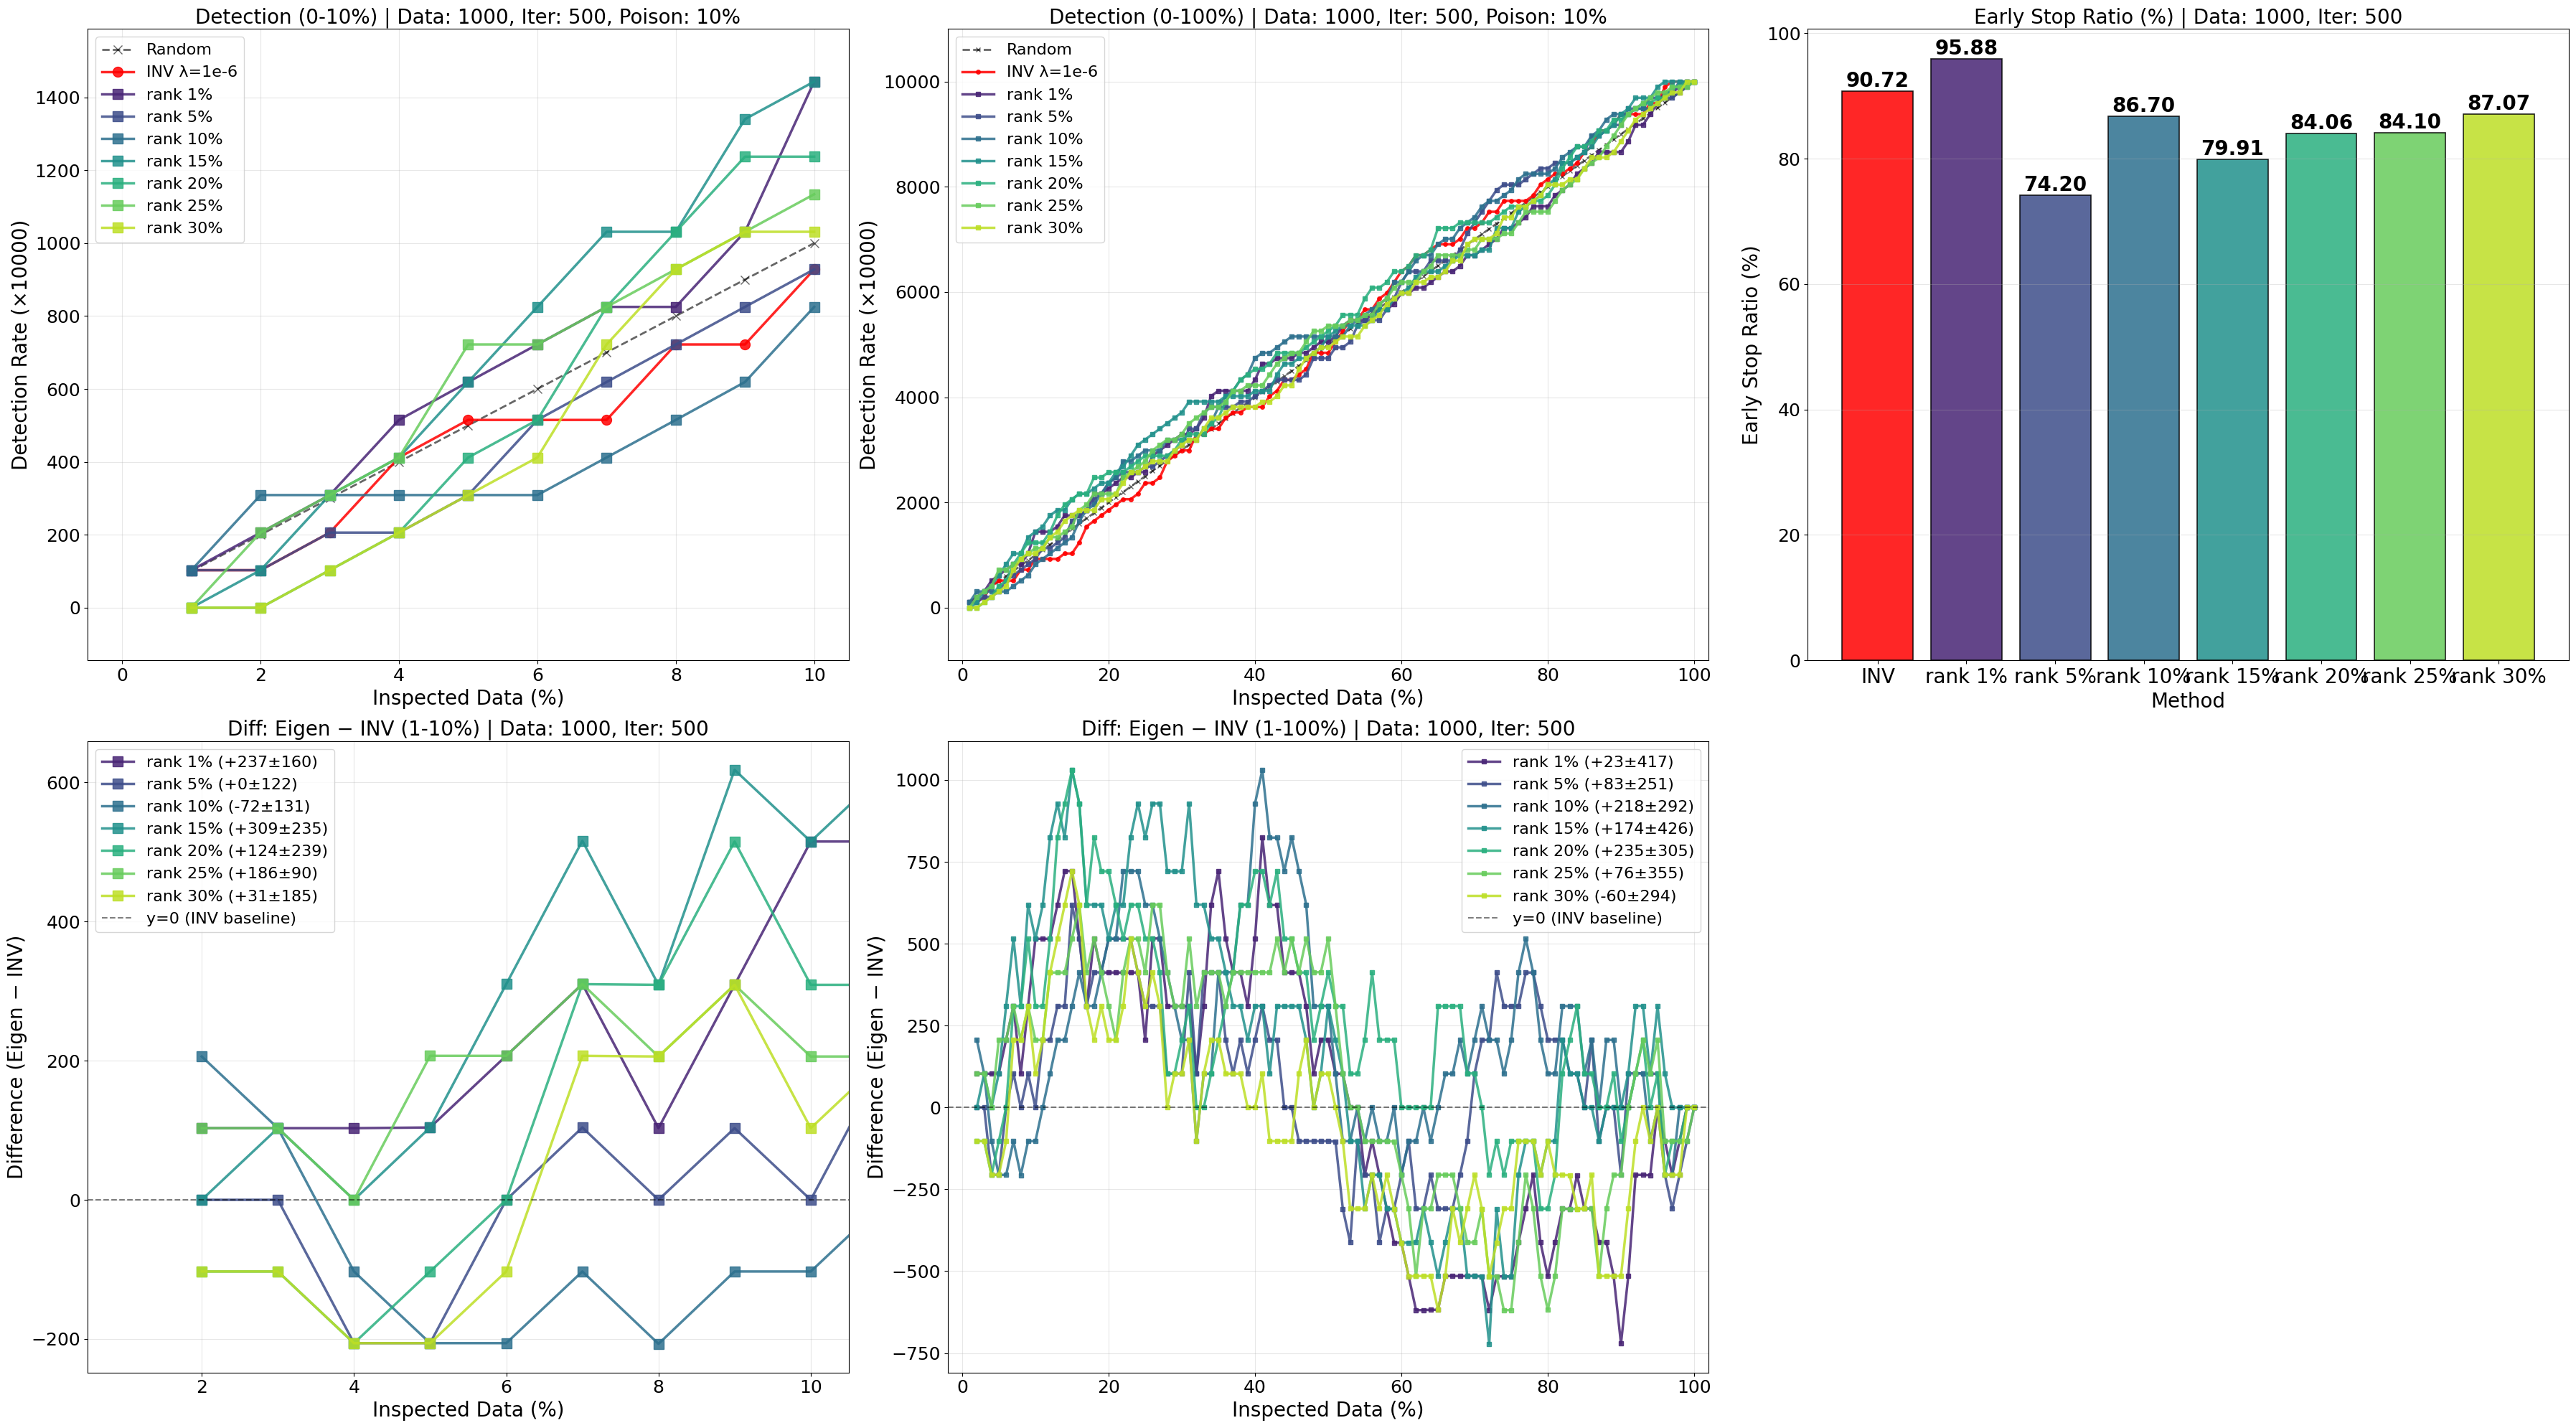

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
iteration = 500
poison_pct = 10
# =========================

inspect_pct = [i for i in range(1, 101)]

# Detection rates (x10000, lowest Shapley first)
# INV baseline
inv_lam1e_6       = [103, 103, 206, 412, 515, 515, 515, 722, 722, 928, 928, 928, 928, 1031, 1031, 1237, 1546, 1649, 1753, 1856, 1959, 2062, 2062, 2165, 2371, 2371, 2474, 2784, 2887, 2990, 2990, 3299, 3299, 3402, 3402, 3608, 3711, 3711, 3814, 3814, 3814, 4021, 4124, 4330, 4330, 4433, 4536, 4845, 4845, 4845, 5052, 5258, 5464, 5464, 5670, 5670, 5876, 5979, 6186, 6392, 6495, 6701, 6701, 6804, 6907, 6907, 6907, 7010, 7216, 7216, 7320, 7526, 7526, 7732, 7732, 7732, 7732, 7835, 8041, 8144, 8247, 8247, 8351, 8454, 8660, 8763, 9072, 9072, 9175, 9381, 9381, 9381, 9381, 9588, 9588, 9897, 10000, 10000, 10000, 10000]
# Eigen Shapley detection rates
r1_eigen_lam1e_2  = [103, 206, 309, 515, 619, 722, 825, 825, 1031, 1443, 1443, 1443, 1546, 1753, 1753, 1753, 1856, 2165, 2165, 2268, 2371, 2474, 2474, 2577, 2577, 2887, 2990, 3093, 3196, 3299, 3299, 3402, 3608, 4021, 4124, 4124, 4124, 4124, 4124, 4330, 4639, 4639, 4742, 4742, 4742, 4845, 4845, 4948, 5052, 5052, 5155, 5361, 5464, 5464, 5464, 5567, 5670, 5670, 5773, 5979, 5979, 6082, 6082, 6186, 6289, 6392, 6392, 6495, 6701, 6701, 6804, 6907, 7010, 7216, 7216, 7320, 7423, 7629, 7629, 7629, 7835, 7938, 8041, 8247, 8351, 8454, 8660, 8660, 8660, 8660, 8866, 9175, 9175, 9381, 9588, 9794, 9794, 9897, 10000, 10000]
r5_eigen_lam1e_2  = [103, 103, 206, 206, 309, 515, 619, 722, 825, 928, 1134, 1134, 1237, 1340, 1649, 1753, 1856, 2062, 2165, 2371, 2474, 2577, 2577, 2577, 2680, 2680, 2784, 2887, 2990, 3093, 3402, 3402, 3711, 3814, 3814, 3814, 3814, 3918, 3918, 4021, 4124, 4227, 4330, 4330, 4330, 4330, 4433, 4742, 4742, 4742, 4948, 4948, 5052, 5361, 5464, 5464, 5464, 5670, 5876, 6186, 6392, 6392, 6392, 6598, 6598, 6598, 6598, 6804, 7113, 7320, 7526, 7732, 7938, 8041, 8041, 8041, 8144, 8247, 8351, 8351, 8454, 8454, 8454, 8557, 8660, 8969, 8969, 9072, 9175, 9175, 9485, 9485, 9485, 9691, 9691, 9691, 9691, 9794, 9897, 10000]
r10_eigen_lam1e_2 = [103, 309, 309, 309, 309, 309, 412, 515, 619, 825, 928, 1031, 1134, 1237, 1340, 1649, 1856, 1959, 2165, 2371, 2474, 2784, 2784, 2887, 2990, 2990, 2990, 3196, 3196, 3196, 3196, 3196, 3402, 3505, 3814, 4021, 4124, 4330, 4433, 4742, 4845, 4845, 4948, 5052, 5155, 5155, 5155, 5155, 5155, 5155, 5155, 5155, 5361, 5464, 5567, 5670, 5773, 5876, 6186, 6186, 6392, 6598, 6701, 6701, 6907, 7010, 7010, 7216, 7320, 7423, 7629, 7732, 7732, 7835, 7938, 8144, 8247, 8247, 8247, 8247, 8351, 8557, 8660, 8763, 8763, 8969, 9072, 9278, 9381, 9381, 9381, 9485, 9485, 9485, 9588, 9691, 9794, 10000, 10000, 10000]
r15_eigen_lam1e_2 = [0, 103, 309, 412, 619, 825, 1031, 1031, 1340, 1443, 1546, 1753, 1856, 1856, 2062, 2165, 2165, 2268, 2371, 2371, 2577, 2680, 2887, 3093, 3196, 3299, 3402, 3505, 3608, 3711, 3918, 3918, 3918, 3918, 3918, 4021, 4021, 4021, 4021, 4124, 4124, 4124, 4433, 4639, 4639, 4742, 4742, 4845, 4948, 5155, 5258, 5361, 5361, 5361, 5361, 5464, 5670, 5670, 5876, 5979, 6082, 6289, 6392, 6392, 6392, 6495, 6598, 6701, 6701, 6701, 6804, 6804, 7216, 7216, 7216, 7526, 7629, 7732, 7835, 8041, 8144, 8454, 8454, 8557, 8660, 8763, 8969, 9072, 9175, 9381, 9485, 9691, 9691, 9691, 9897, 10000, 10000, 10000, 10000, 10000]
r20_eigen_lam1e_2 = [0, 0, 103, 206, 412, 515, 825, 1031, 1237, 1237, 1237, 1443, 1753, 1959, 2062, 2165, 2165, 2474, 2474, 2577, 2577, 2577, 2680, 2784, 2887, 2887, 2887, 2887, 2990, 3196, 3299, 3299, 3299, 3505, 3608, 3918, 4124, 4330, 4433, 4536, 4536, 4639, 4845, 4845, 4845, 4845, 4948, 5052, 5155, 5258, 5361, 5567, 5567, 5567, 5876, 6082, 6082, 6186, 6392, 6392, 6495, 6701, 6701, 6804, 7216, 7216, 7216, 7320, 7320, 7320, 7320, 7320, 7423, 7526, 7629, 7629, 7629, 7732, 7732, 7835, 8041, 8351, 8557, 8763, 8763, 8866, 9072, 9072, 9278, 9278, 9381, 9485, 9588, 9588, 9691, 9691, 9897, 9897, 10000, 10000]
r25_eigen_lam1e_2 = [0, 206, 309, 412, 722, 722, 825, 928, 1031, 1134, 1134, 1340, 1340, 1443, 1546, 1856, 1959, 2165, 2165, 2165, 2165, 2474, 2577, 2680, 2784, 2990, 3093, 3196, 3196, 3299, 3505, 3608, 3711, 3814, 3814, 3918, 4124, 4124, 4227, 4227, 4227, 4433, 4639, 4742, 4845, 4845, 5052, 5258, 5258, 5361, 5361, 5361, 5464, 5464, 5567, 5567, 5773, 5876, 6082, 6186, 6186, 6186, 6392, 6495, 6701, 6701, 6701, 6701, 6804, 6804, 7010, 7010, 7010, 7113, 7113, 7320, 7526, 7526, 7526, 7526, 7732, 7938, 8041, 8144, 8351, 8454, 8557, 8763, 8969, 9175, 9381, 9485, 9588, 9691, 9794, 9794, 9897, 9897, 9897, 10000]
r30_eigen_lam1e_2 = [0, 0, 103, 206, 309, 412, 722, 928, 1031, 1031, 1134, 1340, 1443, 1649, 1753, 1856, 1856, 1856, 2062, 2062, 2165, 2371, 2577, 2577, 2680, 2784, 2784, 2784, 2990, 3093, 3196, 3196, 3402, 3608, 3608, 3711, 3814, 3814, 3814, 3814, 3918, 3918, 4021, 4227, 4227, 4536, 4742, 4845, 4948, 4948, 5052, 5155, 5155, 5155, 5361, 5464, 5567, 5773, 5876, 5979, 5979, 6186, 6186, 6289, 6289, 6392, 6598, 6598, 6907, 7010, 7010, 7010, 7113, 7423, 7423, 7629, 7629, 7732, 7835, 8041, 8041, 8041, 8144, 8144, 8351, 8557, 8557, 8557, 8660, 8866, 9072, 9278, 9381, 9485, 9588, 9691, 9794, 9794, 10000, 10000]

# Early stop ratios (%)
inv_early_stop       = [90.72]
r1_eigen_early_stop  = [95.88]
r5_eigen_early_stop  = [74.20]
r10_eigen_early_stop = [86.70]
r15_eigen_early_stop = [79.91]
r20_eigen_early_stop = [84.06]
r25_eigen_early_stop = [84.10]
r30_eigen_early_stop = [87.07]

# Random baseline (theoretical): inspecting i% finds i% of poisoned
random_baseline = [i * 100 for i in range(1, 101)]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
random_color = 'black'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# Eigen data
eigen_data = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

inspect_pct_10 = inspect_pct[:10]
inspect_pct_1_to_10 = inspect_pct[1:11]
inspect_pct_1_to_99 = inspect_pct[1:]

# ===== Subplot (1,1): Detection Rate 0-10% =====
ax1 = axes[0]

ax1.plot(inspect_pct_10, random_baseline[:10], color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=8, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax1.plot(inspect_pct_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax1.plot(inspect_pct_10, data[:10], color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [random_baseline[:10]] + ([inv_lam1e_6[:10]] if inv_lam1e_6 else []) + [d[0][:10] for d in eigen_data if d[0]]
if all_data_10:
    y_min_10 = min([min(d) for d in all_data_10])
    y_max_10 = max([max(d) for d in all_data_10])
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ax1.set_ylim(y_min_10 - y_margin_10, y_max_10 + y_margin_10)

ax1.set_xlabel('Inspected Data (%)', fontsize=20)
ax1.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax1.set_title(f'Detection (0-10%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax1.legend(fontsize=16, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Detection Rate 0-100% =====
ax2 = axes[1]

ax2.plot(inspect_pct, random_baseline, color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=4, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax2.plot(inspect_pct, inv_lam1e_6, color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=4, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax2.plot(inspect_pct, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

all_data_100 = [random_baseline] + ([inv_lam1e_6] if inv_lam1e_6 else []) + [d[0] for d in eigen_data if d[0]]
if all_data_100:
    y_min_100 = min([min(d) for d in all_data_100])
    y_max_100 = max([max(d) for d in all_data_100])
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ax2.set_ylim(y_min_100 - y_margin_100, y_max_100 + y_margin_100)

ax2.set_xlabel('Inspected Data (%)', fontsize=20)
ax2.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax2.set_title(f'Detection (0-100%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax2.legend(fontsize=16, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 102)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0] if inv_early_stop else 0,
    r1_eigen_early_stop[0] if r1_eigen_early_stop else 0,
    r5_eigen_early_stop[0] if r5_eigen_early_stop else 0,
    r10_eigen_early_stop[0] if r10_eigen_early_stop else 0,
    r15_eigen_early_stop[0] if r15_eigen_early_stop else 0,
    r20_eigen_early_stop[0] if r20_eigen_early_stop else 0,
    r25_eigen_early_stop[0] if r25_eigen_early_stop else 0,
    r30_eigen_early_stop[0] if r30_eigen_early_stop else 0
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Difference (Eigen − INV) 1-10% =====
ax4 = axes[3]

if inv_lam1e_6:
    diff_data_10 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:11]) - np.array(inv_lam1e_6[1:11])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_10.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_10):
        ax4.plot(inspect_pct_1_to_10, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

ax4.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax4.set_xlabel('Inspected Data (%)', fontsize=20)
ax4.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax4.set_title(f'Diff: Eigen − INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Difference (Eigen − INV) 1-100% =====
ax5 = axes[4]

if inv_lam1e_6:
    diff_data_100 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:]) - np.array(inv_lam1e_6[1:])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_100.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_100):
        ax5.plot(inspect_pct_1_to_99, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax5.set_xlabel('Inspected Data (%)', fontsize=20)
ax5.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax5.set_title(f'Diff: Eigen − INV (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(-2, 102)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'wld_seed2025_iter{iteration}_num{num_dp}.png', dpi=100, bbox_inches='tight')
plt.show()

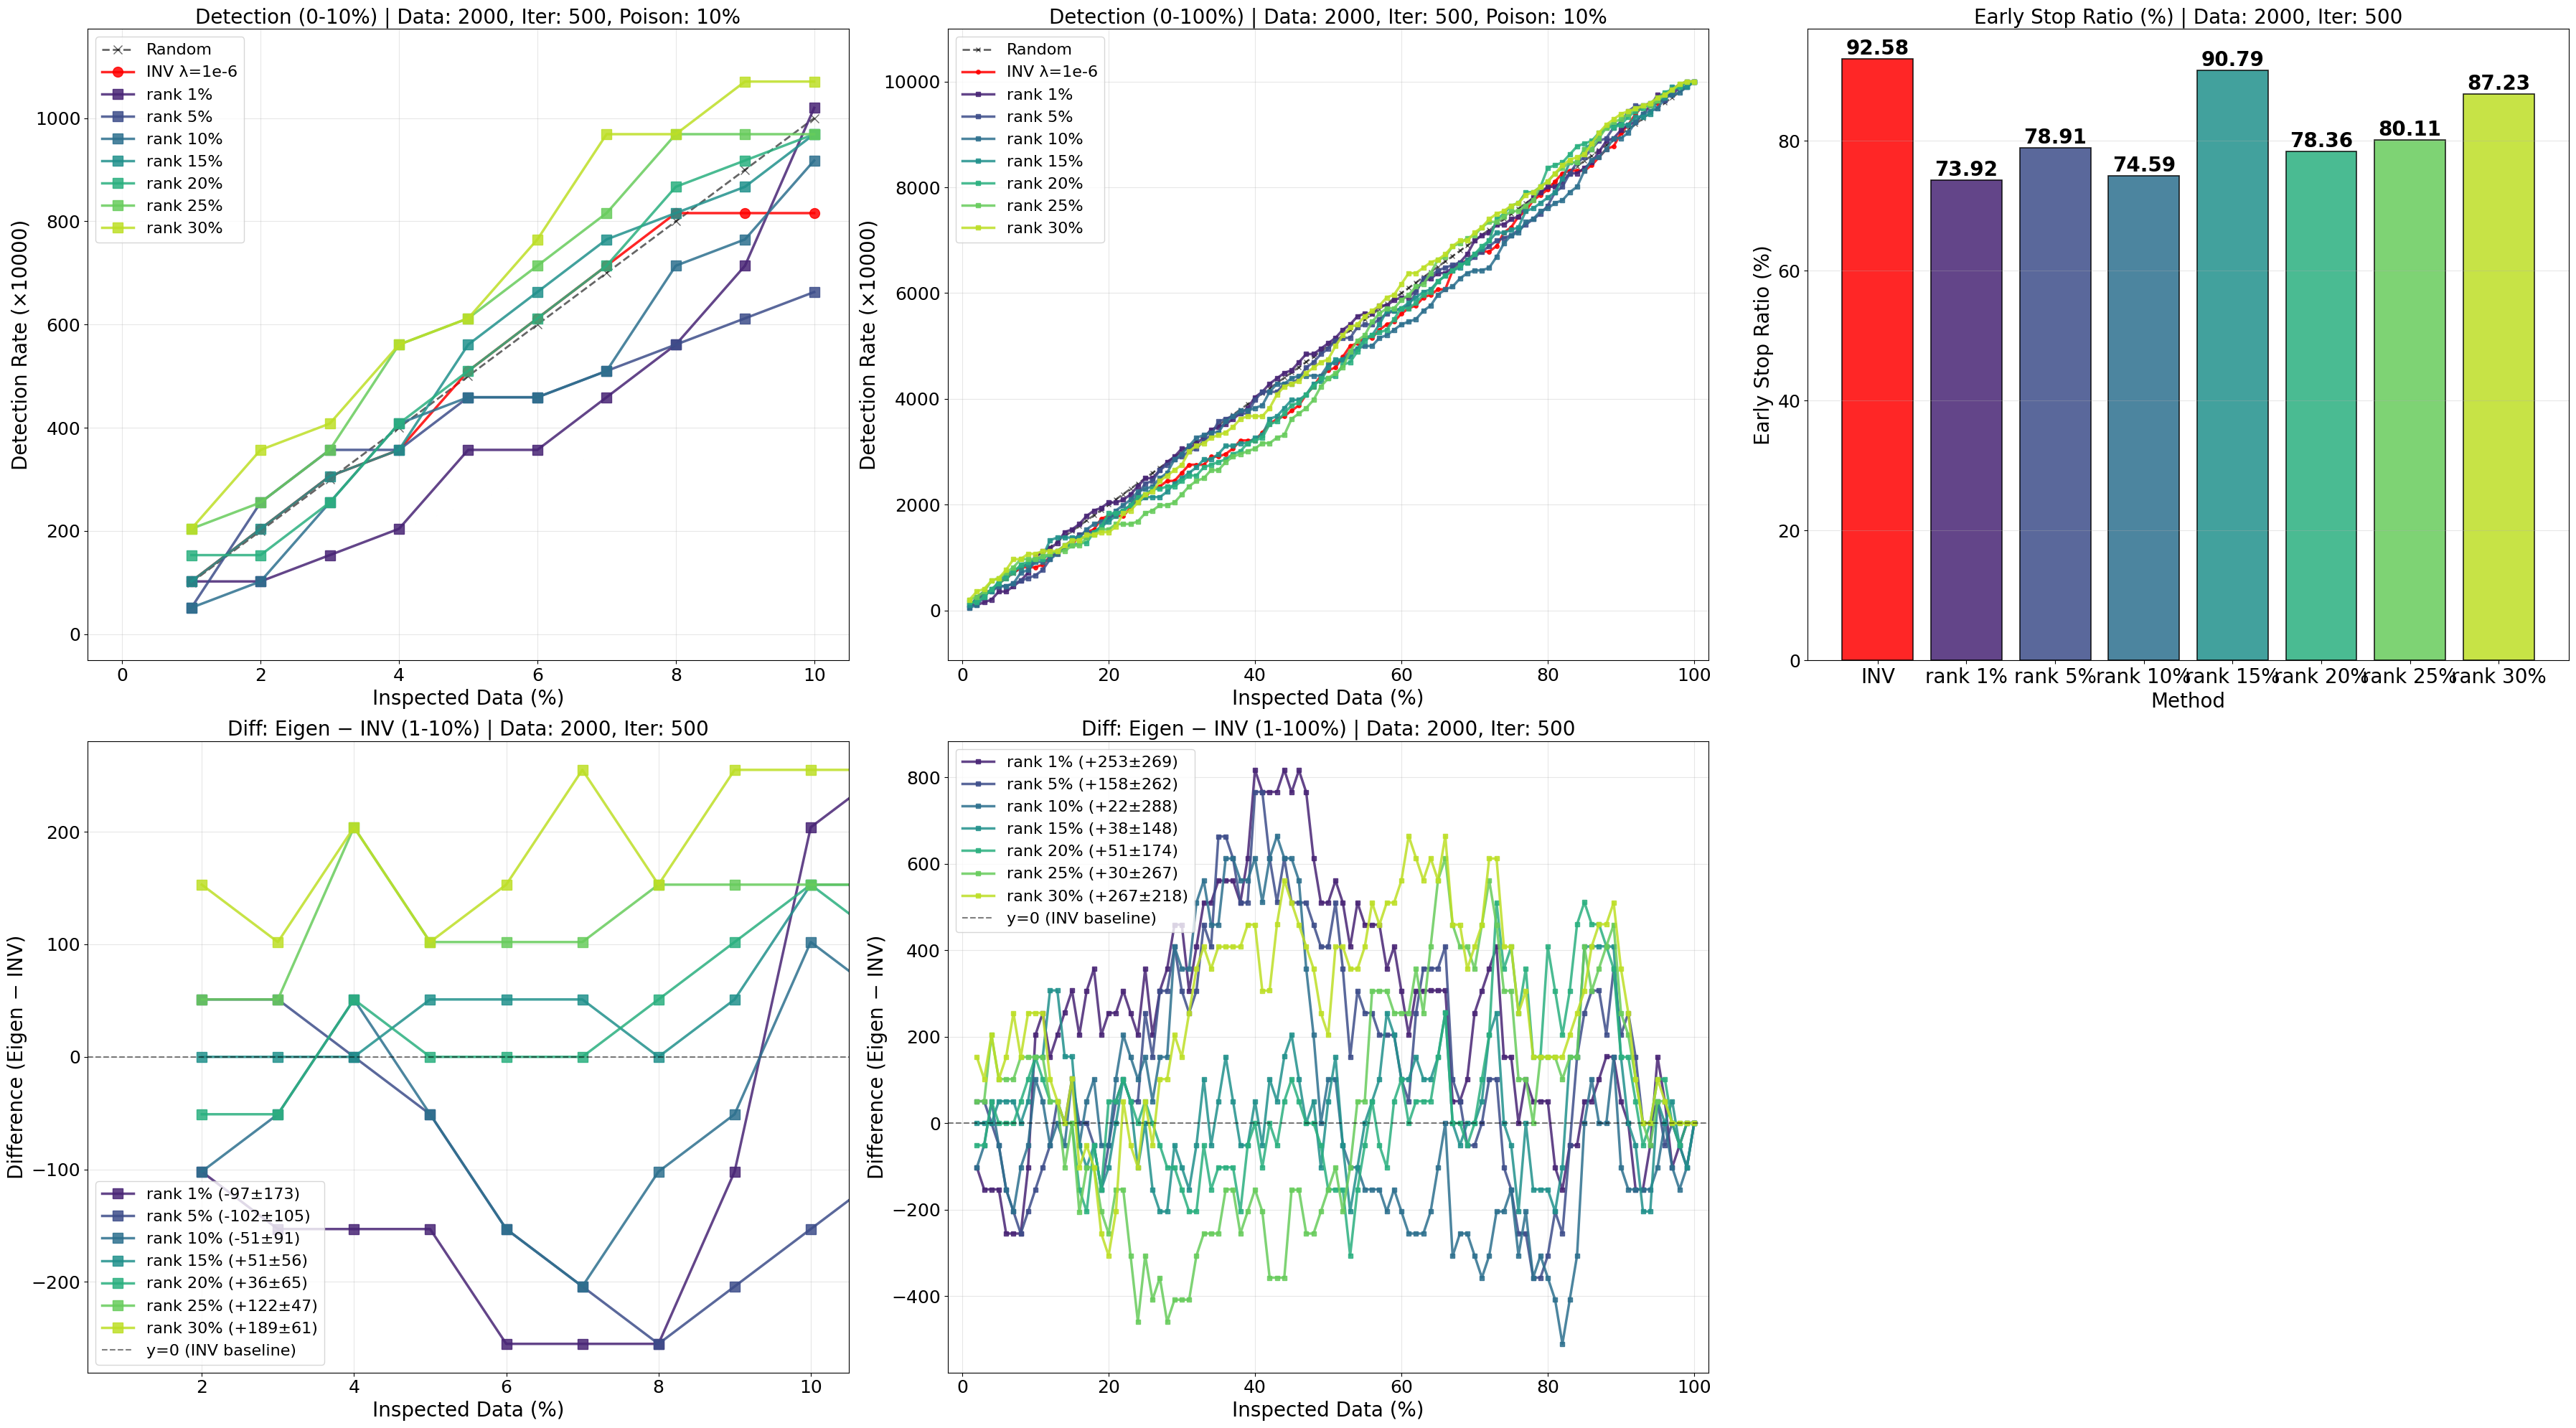

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
iteration = 500
poison_pct = 10
# =========================

inspect_pct = [i for i in range(1, 101)]

# Detection rates (x10000, lowest Shapley first)
# INV baseline
inv_lam1e_6       = [102, 204, 306, 357, 510, 612, 714, 816, 816, 816, 867, 1020, 1071, 1224, 1224, 1429, 1480, 1531, 1735, 1786, 1786, 1786, 1939, 2143, 2143, 2296, 2347, 2449, 2449, 2602, 2755, 2755, 2755, 2908, 2908, 2959, 3061, 3214, 3214, 3214, 3367, 3520, 3622, 3673, 3776, 3878, 4082, 4235, 4439, 4541, 4592, 4796, 5000, 5051, 5153, 5153, 5306, 5408, 5459, 5612, 5714, 5765, 5918, 5969, 6071, 6071, 6429, 6531, 6633, 6735, 6786, 6786, 6888, 7143, 7245, 7449, 7551, 7755, 7857, 7959, 8112, 8265, 8316, 8316, 8316, 8418, 8571, 8724, 8776, 9031, 9184, 9388, 9541, 9592, 9592, 9694, 9847, 9949, 10000, 10000]
# Eigen Shapley detection rates
r1_eigen_lam1e_2  = [102, 102, 153, 204, 357, 357, 459, 561, 714, 1020, 1122, 1173, 1276, 1480, 1531, 1633, 1786, 1888, 1939, 2041, 2041, 2092, 2194, 2347, 2500, 2500, 2653, 2806, 2908, 3061, 3061, 3163, 3265, 3418, 3469, 3520, 3622, 3724, 3827, 4031, 4133, 4286, 4388, 4490, 4541, 4694, 4847, 4847, 4949, 5051, 5153, 5306, 5408, 5561, 5612, 5612, 5765, 5765, 5867, 5918, 5918, 6071, 6224, 6276, 6378, 6378, 6480, 6582, 6735, 6990, 7092, 7143, 7296, 7296, 7398, 7449, 7653, 7806, 7908, 8010, 8010, 8112, 8265, 8265, 8367, 8469, 8673, 8878, 8929, 9082, 9184, 9235, 9388, 9541, 9745, 9745, 9745, 9898, 10000, 10000]
r5_eigen_lam1e_2  = [51, 255, 357, 357, 459, 459, 510, 561, 612, 663, 765, 969, 1122, 1224, 1327, 1429, 1480, 1480, 1582, 1735, 1837, 1888, 1990, 2194, 2398, 2449, 2653, 2755, 2857, 2908, 3010, 3061, 3214, 3316, 3571, 3622, 3673, 3724, 3724, 3980, 4133, 4133, 4133, 4286, 4286, 4388, 4592, 4694, 4847, 4949, 5102, 5153, 5153, 5357, 5408, 5408, 5510, 5612, 5663, 5714, 5765, 6020, 6276, 6327, 6429, 6480, 6531, 6582, 6582, 6684, 6786, 6888, 6990, 7041, 7092, 7194, 7296, 7398, 7500, 7653, 7908, 8010, 8265, 8469, 8571, 8724, 8878, 8929, 9133, 9235, 9439, 9541, 9541, 9592, 9643, 9643, 9847, 9898, 9898, 10000]
r10_eigen_lam1e_2 = [51, 102, 255, 408, 459, 459, 510, 714, 765, 918, 918, 969, 1071, 1173, 1327, 1378, 1531, 1633, 1684, 1735, 1888, 1990, 2092, 2245, 2296, 2347, 2500, 2602, 2857, 2959, 3112, 3265, 3316, 3367, 3367, 3571, 3673, 3776, 3776, 3827, 3878, 4133, 4286, 4286, 4388, 4439, 4439, 4439, 4439, 4643, 4694, 4745, 4898, 4949, 5000, 5000, 5153, 5204, 5306, 5408, 5459, 5510, 5663, 5765, 5969, 6071, 6122, 6276, 6378, 6429, 6429, 6480, 6684, 6939, 7092, 7143, 7347, 7398, 7551, 7602, 7704, 7755, 7908, 8010, 8316, 8520, 8571, 8724, 8929, 8929, 9031, 9235, 9388, 9439, 9490, 9694, 9745, 9796, 9898, 10000]
r15_eigen_lam1e_2 = [102, 204, 306, 357, 561, 663, 765, 816, 867, 969, 1020, 1327, 1378, 1378, 1378, 1378, 1378, 1480, 1582, 1684, 1786, 1888, 1990, 2041, 2143, 2143, 2143, 2245, 2398, 2500, 2602, 2704, 2857, 2857, 2959, 3112, 3112, 3163, 3163, 3265, 3316, 3622, 3673, 3827, 3980, 3980, 4082, 4286, 4337, 4592, 4745, 4745, 4796, 4949, 5153, 5204, 5408, 5663, 5663, 5714, 5816, 5918, 6020, 6071, 6224, 6327, 6429, 6480, 6633, 6735, 6837, 6990, 7143, 7143, 7194, 7245, 7551, 7602, 7704, 7806, 7908, 8163, 8469, 8469, 8724, 8827, 8980, 9133, 9184, 9184, 9184, 9337, 9337, 9388, 9643, 9694, 9898, 9898, 9898, 10000]
r20_eigen_lam1e_2 = [153, 153, 255, 408, 510, 612, 714, 867, 918, 969, 969, 1071, 1122, 1224, 1224, 1276, 1276, 1480, 1582, 1837, 1837, 1888, 1990, 2143, 2194, 2296, 2296, 2347, 2347, 2449, 2551, 2551, 2704, 2755, 2806, 2857, 2959, 3010, 3163, 3214, 3265, 3520, 3571, 3724, 3878, 3929, 4082, 4235, 4388, 4388, 4439, 4643, 4694, 4898, 5102, 5204, 5255, 5306, 5510, 5714, 5714, 5816, 5969, 6020, 6224, 6327, 6429, 6531, 6582, 6735, 6888, 6990, 7398, 7500, 7653, 7704, 7908, 7908, 8010, 8367, 8418, 8469, 8622, 8776, 8827, 8878, 9031, 9133, 9133, 9184, 9337, 9439, 9490, 9592, 9694, 9796, 9847, 9898, 10000, 10000]
r25_eigen_lam1e_2 = [204, 255, 357, 561, 612, 714, 816, 969, 969, 969, 1020, 1071, 1122, 1122, 1224, 1224, 1378, 1429, 1531, 1531, 1633, 1633, 1633, 1684, 1837, 1888, 1990, 1990, 2041, 2194, 2347, 2449, 2500, 2653, 2653, 2806, 2908, 2959, 3010, 3061, 3163, 3163, 3265, 3316, 3622, 3724, 3827, 3980, 4235, 4388, 4490, 4592, 4898, 5102, 5204, 5459, 5612, 5714, 5714, 5867, 5969, 6122, 6173, 6378, 6633, 6684, 6888, 6939, 7041, 7092, 7245, 7347, 7347, 7449, 7551, 7551, 7653, 7755, 8010, 8112, 8265, 8367, 8469, 8469, 8724, 8724, 8929, 9133, 9235, 9286, 9388, 9490, 9541, 9541, 9643, 9745, 9847, 9949, 10000, 10000]
r30_eigen_lam1e_2 = [204, 357, 408, 561, 612, 765, 969, 969, 1071, 1071, 1122, 1122, 1122, 1224, 1327, 1327, 1429, 1429, 1480, 1480, 1582, 1837, 1888, 2041, 2194, 2245, 2449, 2551, 2653, 2755, 3010, 3112, 3163, 3265, 3316, 3367, 3469, 3622, 3673, 3673, 3673, 3827, 4082, 4235, 4286, 4337, 4490, 4592, 4694, 4745, 5000, 5204, 5357, 5408, 5561, 5663, 5765, 5918, 5969, 6173, 6378, 6378, 6480, 6582, 6633, 6735, 6888, 6990, 6990, 7143, 7245, 7398, 7500, 7551, 7653, 7704, 7857, 7908, 8010, 8112, 8265, 8418, 8520, 8571, 8622, 8827, 9031, 9184, 9286, 9388, 9439, 9490, 9541, 9592, 9694, 9745, 9847, 9949, 10000, 10000]

# Early stop ratios (%)
inv_early_stop       = [92.58]
r1_eigen_early_stop  = [73.92]
r5_eigen_early_stop  = [78.91]
r10_eigen_early_stop = [74.59]
r15_eigen_early_stop = [90.79]
r20_eigen_early_stop = [78.36]
r25_eigen_early_stop = [80.11]
r30_eigen_early_stop = [87.23]

# Random baseline (theoretical): inspecting i% finds i% of poisoned
random_baseline = [i * 100 for i in range(1, 101)]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
random_color = 'black'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# Eigen data
eigen_data = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

inspect_pct_10 = inspect_pct[:10]
inspect_pct_1_to_10 = inspect_pct[1:11]
inspect_pct_1_to_99 = inspect_pct[1:]

# ===== Subplot (1,1): Detection Rate 0-10% =====
ax1 = axes[0]

ax1.plot(inspect_pct_10, random_baseline[:10], color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=8, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax1.plot(inspect_pct_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax1.plot(inspect_pct_10, data[:10], color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [random_baseline[:10]] + ([inv_lam1e_6[:10]] if inv_lam1e_6 else []) + [d[0][:10] for d in eigen_data if d[0]]
if all_data_10:
    y_min_10 = min([min(d) for d in all_data_10])
    y_max_10 = max([max(d) for d in all_data_10])
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ax1.set_ylim(y_min_10 - y_margin_10, y_max_10 + y_margin_10)

ax1.set_xlabel('Inspected Data (%)', fontsize=20)
ax1.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax1.set_title(f'Detection (0-10%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax1.legend(fontsize=16, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Detection Rate 0-100% =====
ax2 = axes[1]

ax2.plot(inspect_pct, random_baseline, color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=4, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax2.plot(inspect_pct, inv_lam1e_6, color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=4, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax2.plot(inspect_pct, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

all_data_100 = [random_baseline] + ([inv_lam1e_6] if inv_lam1e_6 else []) + [d[0] for d in eigen_data if d[0]]
if all_data_100:
    y_min_100 = min([min(d) for d in all_data_100])
    y_max_100 = max([max(d) for d in all_data_100])
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ax2.set_ylim(y_min_100 - y_margin_100, y_max_100 + y_margin_100)

ax2.set_xlabel('Inspected Data (%)', fontsize=20)
ax2.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax2.set_title(f'Detection (0-100%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax2.legend(fontsize=16, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 102)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0] if inv_early_stop else 0,
    r1_eigen_early_stop[0] if r1_eigen_early_stop else 0,
    r5_eigen_early_stop[0] if r5_eigen_early_stop else 0,
    r10_eigen_early_stop[0] if r10_eigen_early_stop else 0,
    r15_eigen_early_stop[0] if r15_eigen_early_stop else 0,
    r20_eigen_early_stop[0] if r20_eigen_early_stop else 0,
    r25_eigen_early_stop[0] if r25_eigen_early_stop else 0,
    r30_eigen_early_stop[0] if r30_eigen_early_stop else 0
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Difference (Eigen − INV) 1-10% =====
ax4 = axes[3]

if inv_lam1e_6:
    diff_data_10 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:11]) - np.array(inv_lam1e_6[1:11])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_10.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_10):
        ax4.plot(inspect_pct_1_to_10, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

ax4.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax4.set_xlabel('Inspected Data (%)', fontsize=20)
ax4.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax4.set_title(f'Diff: Eigen − INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Difference (Eigen − INV) 1-100% =====
ax5 = axes[4]

if inv_lam1e_6:
    diff_data_100 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:]) - np.array(inv_lam1e_6[1:])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_100.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_100):
        ax5.plot(inspect_pct_1_to_99, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax5.set_xlabel('Inspected Data (%)', fontsize=20)
ax5.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax5.set_title(f'Diff: Eigen − INV (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(-2, 102)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'wld_seed2025_iter{iteration}_num{num_dp}.png', dpi=100, bbox_inches='tight')
plt.show()

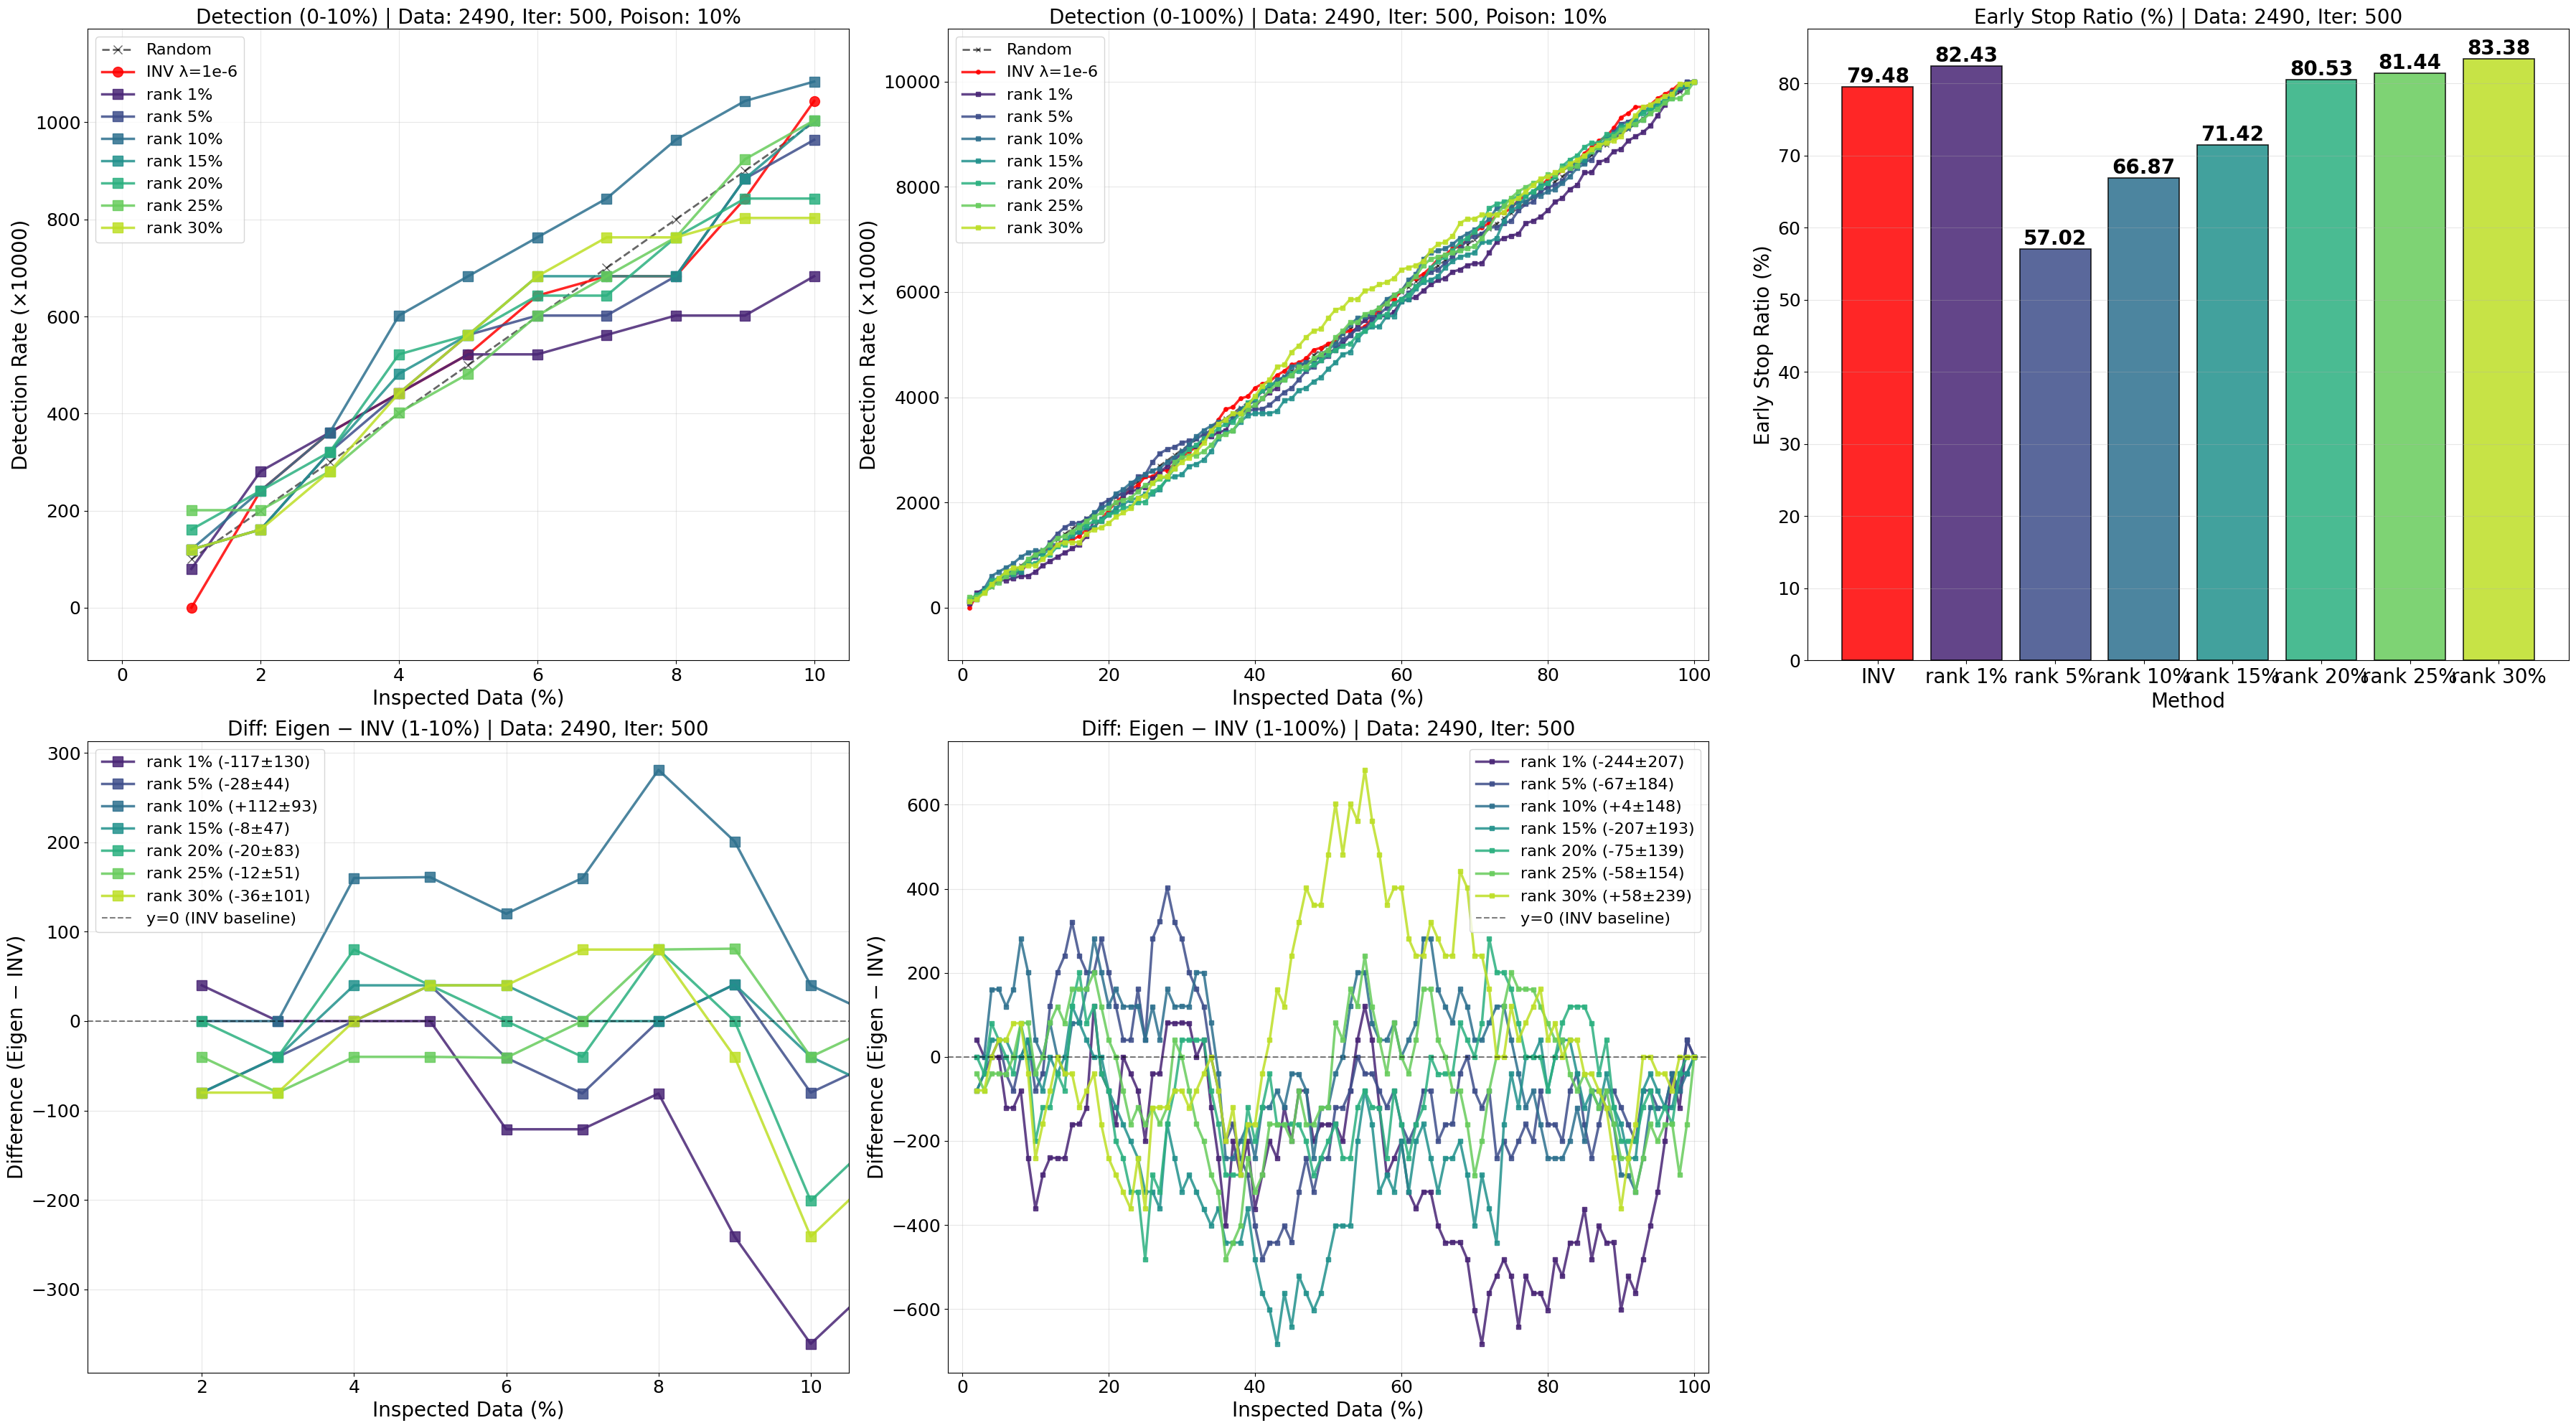

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2490
iteration = 500
poison_pct = 10
# =========================

inspect_pct = [i for i in range(1, 101)]

# Detection rates (x10000, lowest Shapley first)
# INV baseline
inv_lam1e_6       = [0, 241, 361, 442, 522, 643, 683, 683, 843, 1044, 1084, 1124, 1205, 1285, 1285, 1365, 1486, 1526, 1687, 1847, 2008, 2129, 2249, 2329, 2490, 2490, 2610, 2610, 2731, 2851, 2972, 3052, 3173, 3373, 3574, 3775, 3815, 3976, 4016, 4177, 4257, 4297, 4418, 4498, 4618, 4659, 4739, 4900, 4940, 5020, 5060, 5221, 5261, 5301, 5341, 5502, 5663, 5823, 5863, 6024, 6185, 6265, 6345, 6466, 6627, 6707, 6827, 6867, 6988, 7149, 7229, 7309, 7470, 7510, 7590, 7751, 7831, 7912, 7992, 8153, 8193, 8313, 8394, 8474, 8635, 8755, 8876, 8956, 9116, 9317, 9398, 9518, 9518, 9558, 9679, 9759, 9839, 9960, 9960, 10000]
# Eigen Shapley detection rates
r1_eigen_lam1e_2  = [80, 281, 361, 442, 522, 522, 562, 602, 602, 683, 803, 884, 964, 1044, 1124, 1205, 1365, 1647, 1647, 1767, 1847, 2129, 2209, 2249, 2289, 2450, 2570, 2691, 2811, 2932, 3052, 3052, 3213, 3253, 3333, 3373, 3614, 3695, 3815, 3815, 3976, 4096, 4177, 4378, 4418, 4578, 4659, 4699, 4779, 4859, 4900, 5020, 5181, 5341, 5462, 5542, 5542, 5542, 5622, 5823, 5863, 5904, 6024, 6145, 6225, 6265, 6386, 6426, 6506, 6546, 6546, 6747, 6948, 7028, 7068, 7108, 7309, 7349, 7430, 7550, 7711, 7791, 7952, 8032, 8273, 8273, 8474, 8514, 8675, 8715, 8876, 8956, 9036, 9157, 9357, 9558, 9799, 9839, 10000, 10000]
r5_eigen_lam1e_2  = [120, 161, 321, 442, 562, 602, 602, 683, 884, 964, 1044, 1245, 1406, 1526, 1606, 1606, 1687, 1727, 1968, 2048, 2129, 2169, 2289, 2490, 2530, 2771, 2932, 3012, 3052, 3133, 3173, 3213, 3293, 3373, 3494, 3574, 3655, 3735, 3735, 3775, 3775, 3855, 3976, 4096, 4177, 4337, 4498, 4578, 4699, 4779, 4940, 5100, 5181, 5301, 5301, 5462, 5582, 5703, 5783, 5863, 5984, 6104, 6265, 6386, 6426, 6546, 6667, 6827, 6988, 7068, 7108, 7229, 7229, 7309, 7349, 7550, 7671, 7711, 7912, 7992, 8032, 8112, 8313, 8434, 8474, 8514, 8715, 8876, 9036, 9197, 9237, 9317, 9438, 9478, 9558, 9639, 9799, 9880, 10000, 10000]
r10_eigen_lam1e_2 = [120, 241, 361, 602, 683, 763, 843, 964, 1044, 1084, 1084, 1205, 1205, 1245, 1365, 1446, 1647, 1807, 1888, 1968, 2169, 2249, 2369, 2450, 2530, 2610, 2651, 2771, 2851, 2972, 3092, 3253, 3373, 3454, 3534, 3534, 3574, 3775, 3855, 3936, 4137, 4177, 4337, 4378, 4578, 4618, 4659, 4659, 4819, 4900, 5020, 5221, 5382, 5502, 5542, 5582, 5703, 5863, 5944, 6024, 6225, 6345, 6627, 6747, 6787, 6827, 6908, 7028, 7108, 7189, 7269, 7390, 7590, 7631, 7631, 7711, 7711, 7831, 7831, 7912, 7952, 8072, 8193, 8353, 8434, 8675, 8795, 8835, 8956, 9036, 9116, 9197, 9277, 9438, 9558, 9639, 9799, 9880, 9920, 10000]
r15_eigen_lam1e_2 = [120, 161, 321, 482, 562, 683, 683, 683, 884, 1004, 1004, 1124, 1165, 1285, 1406, 1446, 1526, 1526, 1687, 1767, 1888, 1968, 2048, 2088, 2169, 2169, 2249, 2450, 2490, 2530, 2691, 2731, 2811, 2972, 3213, 3333, 3373, 3534, 3655, 3695, 3695, 3695, 3735, 3936, 3976, 4137, 4177, 4297, 4378, 4538, 4659, 4819, 4859, 5100, 5261, 5341, 5341, 5542, 5542, 5823, 5863, 6064, 6185, 6225, 6305, 6466, 6586, 6667, 6707, 6747, 6948, 6948, 7028, 7349, 7550, 7631, 7831, 7912, 8032, 8072, 8193, 8353, 8434, 8434, 8514, 8675, 8755, 8916, 8996, 9157, 9157, 9277, 9438, 9518, 9598, 9639, 9719, 9920, 9920, 10000]
r20_eigen_lam1e_2 = [161, 241, 321, 522, 562, 643, 643, 763, 843, 843, 964, 1004, 1165, 1205, 1406, 1566, 1566, 1647, 1647, 1767, 1807, 1888, 1928, 2008, 2008, 2209, 2289, 2450, 2651, 2892, 3012, 3092, 3213, 3293, 3414, 3494, 3534, 3695, 3896, 3976, 4137, 4257, 4257, 4337, 4458, 4498, 4538, 4618, 4699, 4819, 4900, 4980, 5020, 5181, 5261, 5382, 5542, 5582, 5783, 5863, 5944, 6104, 6225, 6466, 6586, 6667, 6787, 6948, 7028, 7149, 7309, 7590, 7671, 7711, 7751, 7831, 7831, 7912, 7992, 8072, 8193, 8394, 8514, 8594, 8755, 8835, 8835, 8996, 8996, 9116, 9197, 9317, 9398, 9478, 9518, 9639, 9679, 9920, 9960, 10000]
r25_eigen_lam1e_2 = [201, 201, 281, 402, 482, 602, 683, 763, 924, 1004, 1084, 1205, 1325, 1365, 1446, 1526, 1647, 1727, 1807, 1888, 2008, 2048, 2088, 2209, 2329, 2369, 2450, 2490, 2771, 2851, 2892, 2892, 2972, 3092, 3253, 3293, 3373, 3574, 3775, 3855, 3976, 4137, 4257, 4337, 4418, 4578, 4578, 4739, 4819, 4900, 5141, 5261, 5422, 5422, 5582, 5622, 5703, 5783, 5944, 6024, 6145, 6305, 6506, 6627, 6667, 6707, 6747, 6787, 6827, 6867, 7028, 7229, 7470, 7631, 7791, 7912, 7992, 8072, 8112, 8233, 8233, 8353, 8353, 8394, 8594, 8675, 8755, 8876, 8956, 9076, 9157, 9197, 9277, 9398, 9478, 9598, 9679, 9679, 9799, 10000]
r30_eigen_lam1e_2 = [120, 161, 281, 442, 562, 683, 763, 763, 803, 803, 924, 1044, 1205, 1245, 1245, 1245, 1406, 1486, 1526, 1606, 1727, 1807, 1888, 2088, 2129, 2369, 2490, 2490, 2651, 2771, 2851, 2972, 3133, 3373, 3494, 3574, 3695, 3695, 3855, 4016, 4217, 4337, 4578, 4618, 4859, 4980, 5141, 5261, 5301, 5502, 5663, 5703, 5863, 5863, 6024, 6064, 6145, 6185, 6265, 6426, 6466, 6506, 6586, 6787, 6908, 6948, 7068, 7309, 7390, 7390, 7470, 7470, 7470, 7510, 7711, 7791, 7912, 8032, 8153, 8193, 8273, 8313, 8434, 8514, 8594, 8715, 8795, 8835, 8876, 8956, 9157, 9357, 9518, 9558, 9639, 9719, 9759, 9960, 9960, 10000]

# Early stop ratios (%)
inv_early_stop       = [79.48]
r1_eigen_early_stop  = [82.43]
r5_eigen_early_stop  = [57.02]
r10_eigen_early_stop = [66.87]
r15_eigen_early_stop = [71.42]
r20_eigen_early_stop = [80.53]
r25_eigen_early_stop = [81.44]
r30_eigen_early_stop = [83.38]

# Random baseline (theoretical): inspecting i% finds i% of poisoned
random_baseline = [i * 100 for i in range(1, 101)]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
random_color = 'black'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# Eigen data
eigen_data = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

inspect_pct_10 = inspect_pct[:10]
inspect_pct_1_to_10 = inspect_pct[1:11]
inspect_pct_1_to_99 = inspect_pct[1:]

# ===== Subplot (1,1): Detection Rate 0-10% =====
ax1 = axes[0]

ax1.plot(inspect_pct_10, random_baseline[:10], color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=8, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax1.plot(inspect_pct_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax1.plot(inspect_pct_10, data[:10], color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [random_baseline[:10]] + ([inv_lam1e_6[:10]] if inv_lam1e_6 else []) + [d[0][:10] for d in eigen_data if d[0]]
if all_data_10:
    y_min_10 = min([min(d) for d in all_data_10])
    y_max_10 = max([max(d) for d in all_data_10])
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ax1.set_ylim(y_min_10 - y_margin_10, y_max_10 + y_margin_10)

ax1.set_xlabel('Inspected Data (%)', fontsize=20)
ax1.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax1.set_title(f'Detection (0-10%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax1.legend(fontsize=16, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Detection Rate 0-100% =====
ax2 = axes[1]

ax2.plot(inspect_pct, random_baseline, color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=4, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax2.plot(inspect_pct, inv_lam1e_6, color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=4, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax2.plot(inspect_pct, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

all_data_100 = [random_baseline] + ([inv_lam1e_6] if inv_lam1e_6 else []) + [d[0] for d in eigen_data if d[0]]
if all_data_100:
    y_min_100 = min([min(d) for d in all_data_100])
    y_max_100 = max([max(d) for d in all_data_100])
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ax2.set_ylim(y_min_100 - y_margin_100, y_max_100 + y_margin_100)

ax2.set_xlabel('Inspected Data (%)', fontsize=20)
ax2.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax2.set_title(f'Detection (0-100%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax2.legend(fontsize=16, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 102)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0] if inv_early_stop else 0,
    r1_eigen_early_stop[0] if r1_eigen_early_stop else 0,
    r5_eigen_early_stop[0] if r5_eigen_early_stop else 0,
    r10_eigen_early_stop[0] if r10_eigen_early_stop else 0,
    r15_eigen_early_stop[0] if r15_eigen_early_stop else 0,
    r20_eigen_early_stop[0] if r20_eigen_early_stop else 0,
    r25_eigen_early_stop[0] if r25_eigen_early_stop else 0,
    r30_eigen_early_stop[0] if r30_eigen_early_stop else 0
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Difference (Eigen − INV) 1-10% =====
ax4 = axes[3]

if inv_lam1e_6:
    diff_data_10 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:11]) - np.array(inv_lam1e_6[1:11])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_10.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_10):
        ax4.plot(inspect_pct_1_to_10, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

ax4.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax4.set_xlabel('Inspected Data (%)', fontsize=20)
ax4.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax4.set_title(f'Diff: Eigen − INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Difference (Eigen − INV) 1-100% =====
ax5 = axes[4]

if inv_lam1e_6:
    diff_data_100 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:]) - np.array(inv_lam1e_6[1:])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_100.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_100):
        ax5.plot(inspect_pct_1_to_99, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax5.set_xlabel('Inspected Data (%)', fontsize=20)
ax5.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax5.set_title(f'Diff: Eigen − INV (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(-2, 102)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'wld_seed2025_iter{iteration}_num{num_dp}.png', dpi=100, bbox_inches='tight')
plt.show()